In [1]:
from IPython.core.display import Image
from langgraph.constants import START, END

from src.agent.graph import (
    GENERATE_SEARCH_NODE,
    WEB_SEARCH_NODE,
    CRITIQUE_NODE,
    FINAL_ANSWER_NODE)

from src.agent.graph import (
    web_search,
    critique,
    final_answer,
    generate_search,
    send_to_web_search,
    route_evaluate
)
from src.agent.configuration import Configuration
from src.agent.state import OverallState
from langgraph.graph import StateGraph


In [ ]:

# 创建我们的Agent图
builder = StateGraph(OverallState, config_schema=Configuration)



# 定义图中的节点
builder.add_node(GENERATE_SEARCH_NODE, generate_search)
builder.add_node(WEB_SEARCH_NODE, web_search)
builder.add_node(CRITIQUE_NODE, critique)
builder.add_node(FINAL_ANSWER_NODE, final_answer)

# 将入口点设置为`generate_query`
# 这意味着这个节点是第一个被调用的
builder.add_edge(START, GENERATE_SEARCH_NODE)
# 添加条件边以在并行分支中继续搜索查询
builder.add_conditional_edges(
    GENERATE_SEARCH_NODE, send_to_web_search, [WEB_SEARCH_NODE]
)
# 对进度进行评估
builder.add_edge(WEB_SEARCH_NODE, CRITIQUE_NODE)
# 评估后决定下一步如何做
builder.add_conditional_edges(
    CRITIQUE_NODE, route_evaluate, [WEB_SEARCH_NODE, FINAL_ANSWER_NODE]
)
# 最终确定答案
builder.add_edge(FINAL_ANSWER_NODE, END)

# 编译图
graph = builder.compile(name="pro-research-agent")


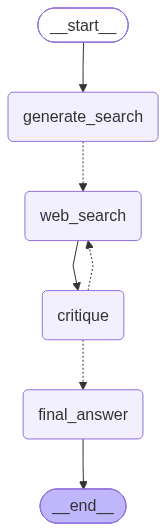

---
config:
  flowchart:
    curve: linear
---
graph TD;
        __start__([<p>__start__</p>]):::first
        generate_search(generate_search)
        web_search(web_search)
        critique(critique)
        final_answer(final_answer)
        __end__([<p>__end__</p>]):::last
        __start__ --> generate_search;
        critique -.-> final_answer;
        critique -.-> web_search;
        generate_search -.-> web_search;
        web_search --> critique;
        final_answer --> __end__;
        classDef default fill:#f2f0ff,line-height:1.2
        classDef first fill-opacity:0
        classDef last fill:#bfb6fc

In [12]:

display(Image(graph.get_graph().draw_mermaid_png()))


In [14]:
from rich import print as rprint
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	generate_search(generate_search)
	web_search(web_search)
	critique(critique)
	final_answer(final_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> generate_search;
	critique -.-> final_answer;
	critique -.-> web_search;
	generate_search -.-> web_search;
	web_search --> critique;
	final_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [3]:

model = 'MiniMax-M3'
deep_research_topic = '现在企业级的 AI Agent 落地方案深度调研'
initial_search_query_count = 2
input = OverallState(messages=[deep_research_topic])
res = graph.invoke(input=input)

rprint(res)

2026-09-02 12:07:33.563 | INFO     | src.agent.graph:generate_search:55 - LangGraph节点开始运行.....，配置：[{'configurable': {'__pregel_runtime': Runtime(context=None, store=None, stream_writer=<function Pregel.stream.<locals>.stream_writer at 0x10bd4cf40>, heartbeat=<function _no_op_heartbeat at 0x10a52b100>, previous=None, execution_info=ExecutionInfo(checkpoint_id='1f1a683d-2f88-64ba-8000-15167f7898f4', checkpoint_ns='generate_search:e39eb25f-d616-7e59-2ac6-91cadd951f37', task_id='e39eb25f-d616-7e59-2ac6-91cadd951f37', thread_id=None, run_id=None, node_attempt=1, node_first_attempt_time=1788322053.562596), server_info=None, control=<langgraph.runtime.RunControl object at 0x10bc989d0>), '__pregel_replay_state': None, '__pregel_task_id': 'e39eb25f-d616-7e59-2ac6-91cadd951f37', '__pregel_send': <built-in method extend of collections.deque object at 0x10bcd7880>, '__pregel_read': functools.partial(<function local_read at 0x10a5400e0>, PregelScratchpad(step=1, stop=10007, call_counter=<langgraph.

{
    'messages': [
        HumanMessage(
            content='现在企业级的 AI Agent 落地方案深度调研',
            additional_kwargs={},
            response_metadata={},
            id='a67c9f27-d18d-4c65-9dc1-a168deb339f6'
        ),
        AIMessage(
            content='# 企业级AI Agent落地方案深度调研报告\n\n**报告日期**：2026年9月\n\n---\n\n## 
摘要\n\n随着大语言模型（LLM）技术的快速成熟，AI 
Agent（人工智能代理）正从概念验证走向企业级规模化部署。本报告基于IDC、NVIDIA、中国信通院等权威机构的调研数据，对202
4-2026年企业级AI Agent的市场现状、技术架构、主流框架、实施挑战及解决方案进行了系统性梳理。研究表明，全球AI 
Agent市场规模预计从2024年的51亿美元增长至2030年的470亿美元以上，年复合增长率超过40%。然而，行业普遍面临实施成功率偏
低的困境——超过60%的AI智能体项目难以实现预期业务价值，其中框架选型错误是导致失败的首要原因（占比43%）。本报告旨在为
企业决策者提供AI Agent落地的全面参考框架，助力企业在数字化转型中把握智能体技术的战略机遇。\n\n---\n\n## 
一、研究背景与市场概况\n\n### 1.1 
研究背景\n\n人工智能技术正经历从“对话生成”向“自主执行”的范式转变。传统的AI助手能够理解用户问题并生成优质回答，但这
本质上仍是被动的响应模式——用户需要具备提出正确问题的能力，且AI无法将决策转化为实际动作。进入2024年后，随着大语言模
型推理能力的显著提升，以及工具调用、长期记忆、多步骤规划等核心技术的突破，AI 
Agent开始具备独立承担任务、协同达成目标的“数字化协作者”能力[AI 
Agent商业实战进化四部曲](https://blog.csdn.net/2401_84204413/article/details/161598787)。\n\n2026年被视为企业级AI智
能体的规模化落地元年。AI已从试点阶段转向规模化应用，技术成熟度的提升为企业部署AI 
Agent提供了前所未有的窗口期。然而，机遇与挑战并存——多数企业的Agent应用成熟度仍停留在探索试验级和局部赋能级，距离真
正“理解业务逻辑、支撑战略决策”的商业智能体尚存在显著差距[AI 
Agent数据分析企业落地](https://hainan.ifeng.com/c/8w27Pv14JC9)。\n\n### 1.2 市场规模与增长态势\n\n全球AI 
Agent市场正处于高速增长轨道。据公开行业报告测算，2024年全球AI 
Agent市场规模已达**51亿美元**，预计2030年将突破**470-471亿美元**，年复合增长率超过40%。这一增长动力主要来自三个方面
：一是企业数字化转型对自动化智能解决方案的迫切需求；二是大语言模型技术成熟度提升带来的部署可行性增强；三是AI 
Agent在金融、医疗、制造、零售等多个垂直领域的应用场景不断拓展[AI 
Agent数据分析企业落地](https://hainan.ifeng.com/c/8w27Pv14JC9)。\n\n从区域市场来看，中国市场的增速尤为突出。2026年
，中国企业AI 
Agent采纳率预计突破**35%**，而2024年这一数字仅为8%。企业级AI应用渗透率已超过45%，显示出强劲的市场活力。这一现象的背
后是中国企业对于降本增效的强烈诉求，以及政策层面对人工智能产业的支持引导[AI 
Agent商业实战进化四部曲](https://blog.csdn.net/2401_84204413/article/details/161598787)。\n\n### 1.3 
企业采纳现状与成熟度分析\n\n尽管市场增长势头强劲，但企业AI 
Agent的实际采纳深度仍存在显著差异。根据行业调研数据，**65%的金融机构正在积极使用AI**（较2024年的45%跃升20个百分点）
，**84%的企业认为开源对其AI战略至关重要**，**89%的受访者确认AI同时提升了收入和降低了成本**[NVIDIA金融服务AI报告](ht
tps://www.sgpjbg.com/info/3fbc62187ee91da132af0fcf45bdf3a0.html)。这些数据表明，头部企业的AI 
Agent应用已进入实质性产出阶段。\n\n然而，更值得关注的是行业普遍面临的成功率困境。**超过60%的AI智能体项目难以实现预
期业务价值**，这一数据揭示了技术潜力与实际落地效果之间的巨大鸿沟[企业Agent采购参考](https://www.163.com/dy/article/
L5DKS2440518TA2V.html)。多数企业的Agent应用成熟度仍停留在探索试验级（仅做POC验证）和局部赋能级（单一场景试点），距
离真正支撑复杂业务决策的成熟智能体尚有较长距离。\n\n---\n\n## 二、AI Agent核心概念与技术架构\n\n### 2.1 
Agent与Chatbot的本质区别\n\n理解AI 
Agent的价值，首先需要厘清其与传统Chatbot的本质差异。虽然两者都以自然语言交互为基础，但在能力边界和应用范式上存在根
本性区别：\n\n| 对比维度 | 传统Chatbot | AI Agent |\n|---------|-------------|----------|\n| **交互方式** | 
一问一答，被动响应 | 接收目标，自主执行 |\n| **输出形式** | 仅输出文本 | 文本+实际行动（订票、发邮件、调用系统） 
|\n| **信息获取** | 依赖训练时的固有知识 | 实时查询、即时调用外部工具 |\n| **记忆跨度** | 仅限当前对话窗口 | 
跨步骤、跨会话持续积累 |\n| **出错处理** | 可能生成错误回答（幻觉） | 检测错误并自主修正 |\n| **核心价值** | 
生成优质回答 | 完成实际任务 |\n\n简言之，Chatbot是“具备语言能力的顾问”，而Agent是“具备执行能力的助手”[AI 
Agent商业实战进化四部曲](https://blog.csdn.net/2401_84204413/article/details/161598787)。这一区别从根本上决定了AI 
Agent能够承担更复杂、更具商业价值的业务流程自动化任务。\n\n### 2.2 Agent标准架构解析\n\n完整的AI 
Agent架构包含五大核心组件，这些组件相互协作，共同支撑智能体的自主决策与执行能力：\n\n#### 2.2.1 
核心组件体系\n\n**（1）大脑（LLM）**\n\n作为Agent的核心推理引擎，大语言模型负责理解用户目标、权衡行动方案、输出行动
指令。2026年，推理引擎正从“背答案”进化为“会思考”。OpenAI 
o1将“推理时计算”确立为独立Scaling维度，DeepSeek-R1用纯强化学习证明了推理能力可在无人工标注思维链数据的情况下涌现[智
能体时代技术跃迁](https://cloud.tencent.com/developer/article/2674824)。这意味着现代Agent不仅能够回答问题，更能够进
行复杂的多步推理和决策规划。\n\n**（2）手脚（Tools）**\n\nTools组件负责将大模型的决策转化为实际动作，包括网络搜索、
API调用、文件生成、数据写入等。在企业场景中，Tools的范畴通常扩展至ERP系统操作、CRM数据查询、报表生成、邮件发送等业
务系统交互能力。工具调用的可靠性是2026年工程瓶颈突破的关键方向之一，通过严格鉴权与回滚机制的API网关，实现安全、原子
化地调用企业内部系统接口[Dify平台](https://blog.csdn.net/weixin_31971181/article/details/162023740)。\n\n**（3）记
忆（Memory）**\n\n记忆系统解决了传统对话系统“每轮从零开始”的痛点，支持Agent在跨步骤、跨会话的场景中保持状态连续性和
偏好一致性。记忆系统的演进经历了三个阶段：1.0阶段采用全量上下文注入（受token限制），2.0阶段采用RAG检索增强生成（存
在语义碎片化问题），2025-2026年则通过分层记忆架构实现突破——短期意图存在Redis热存储，长期偏好存进加密关系型数据库，
彻底规避向量检索的模糊性[智能体时代技术跃迁](https://cloud.tencent.com/developer/article/2674824)。\n\n**（4）规划
（Planning）**\n\n规划模块负责将复杂目标拆解为可执行的步骤序列，并根据实时反馈动态调整执行路径。这一能力对于处理企
业级复杂业务流程至关重要，例如将“完成季度销售报告”这一目标分解为“提取销售数据→分析同比环比→生成可视化图表→撰写分析
结论”等子任务，并按优先级排序执行。\n\n**（5）反思（Reflection）**\n\n反思机制使Agent具备自我纠错能力。当